In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

**1. Data Understanding**

In [33]:
df=pd.read_csv("/content/Loan Approval prediction dataset.zip")

In [34]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [35]:
df.shape

(614, 13)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [37]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**2. DATA PREPROCESSING**

In [38]:
df.info()
print("/Missing Values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
/Missing Values per column:
Loan_ID               0
Gender               13
Married               3
Dependents  

In [39]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [40]:
df.duplicated().sum()

np.int64(0)

**Data Visualization**

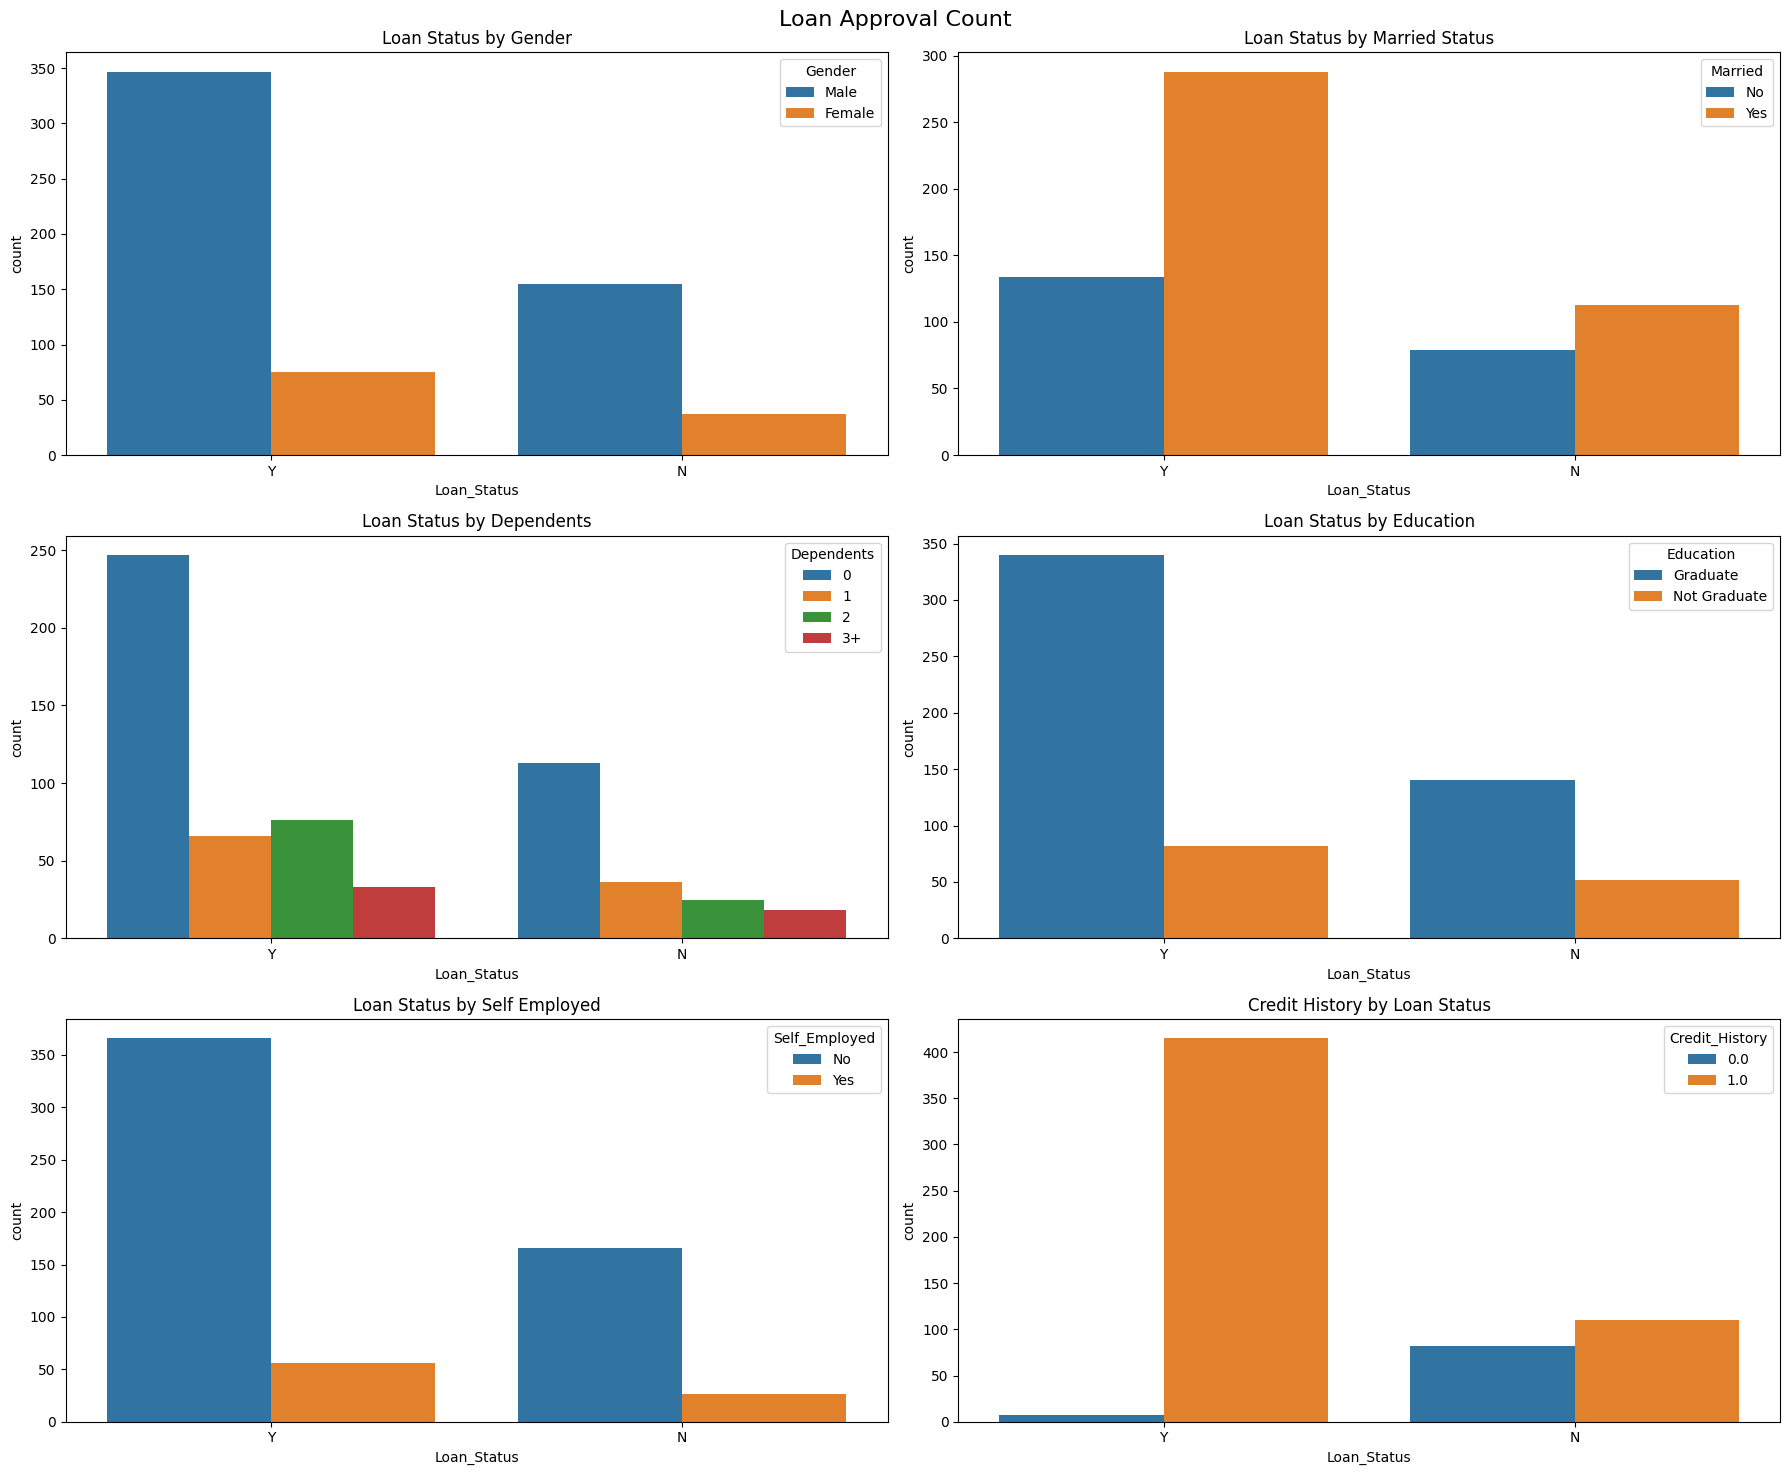

In [41]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()
sns.countplot(x='Loan_Status', hue='Gender', data=df, ax=axes[0])
axes[0].set_title('Loan Status by Gender')
sns.countplot(x='Loan_Status', hue='Married', data=df, ax=axes[1])
axes[1].set_title('Loan Status by Married Status')
sns.countplot(x='Loan_Status', hue='Dependents', data=df, ax=axes[2])
axes[2].set_title('Loan Status by Dependents')
sns.countplot(x='Loan_Status', hue='Education', data=df, ax=axes[3])
axes[3].set_title('Loan Status by Education')
sns.countplot(x='Loan_Status', hue='Self_Employed', data=df, ax=axes[4])
axes[4].set_title('Loan Status by Self Employed')
sns.countplot(hue='Credit_History', x='Loan_Status', data=df, ax=axes[5])
axes[5].set_title('Credit History by Loan Status')

for ax in axes[7:]:
    ax.axis('off')

fig.suptitle('Loan Approval Count', fontsize=16)
plt.tight_layout()
plt.show()

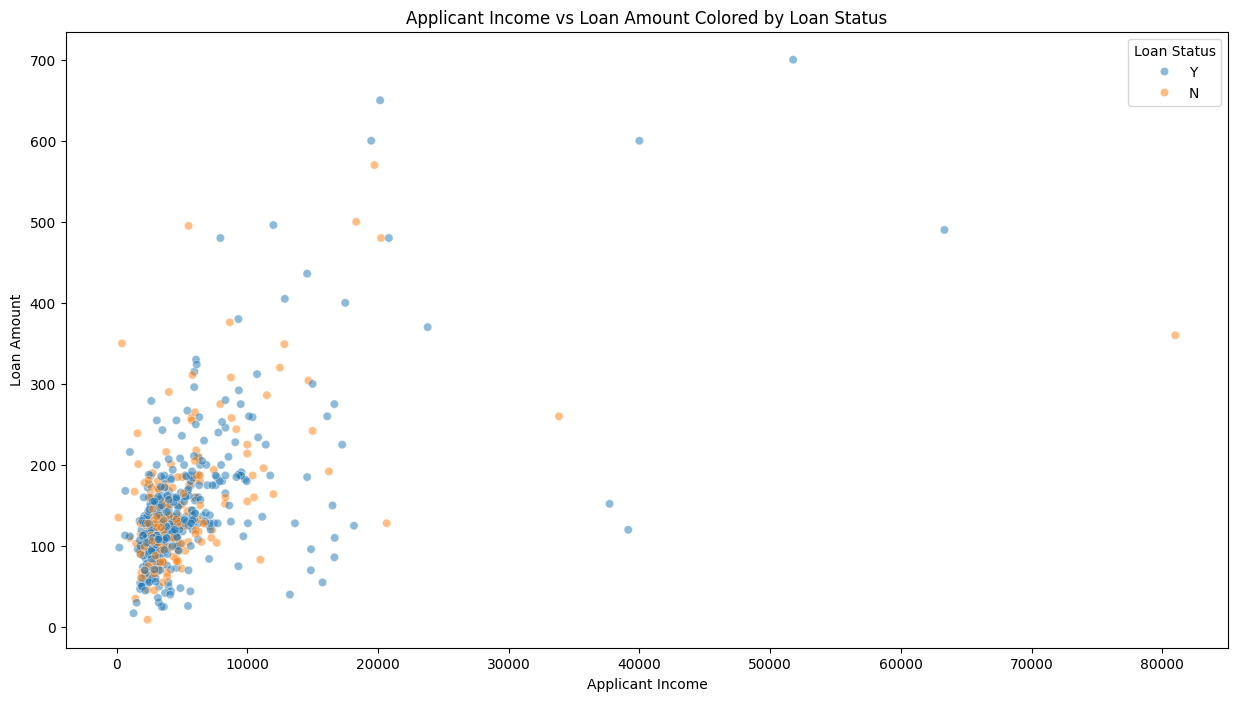

In [42]:
plt.figure(figsize=(15,8))
sns.scatterplot(data=df,x='ApplicantIncome',y='LoanAmount',hue='Loan_Status',alpha=0.5)
plt.title('Applicant Income vs Loan Amount Colored by Loan Status')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.show()

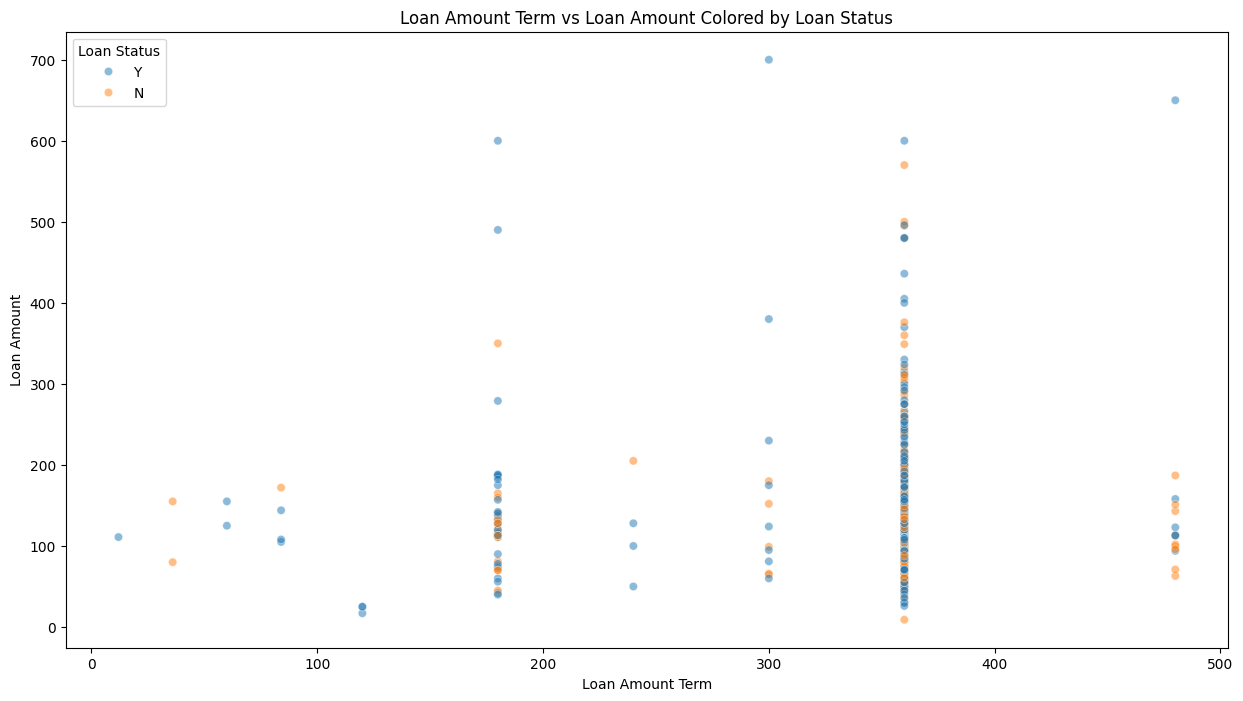

In [43]:
plt.figure(figsize=(15,8))
sns.scatterplot(data=df,x='Loan_Amount_Term',y='LoanAmount',hue='Loan_Status',alpha=0.5)
plt.title('Loan Amount Term vs Loan Amount Colored by Loan Status')
plt.xlabel('Loan Amount Term')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.show()

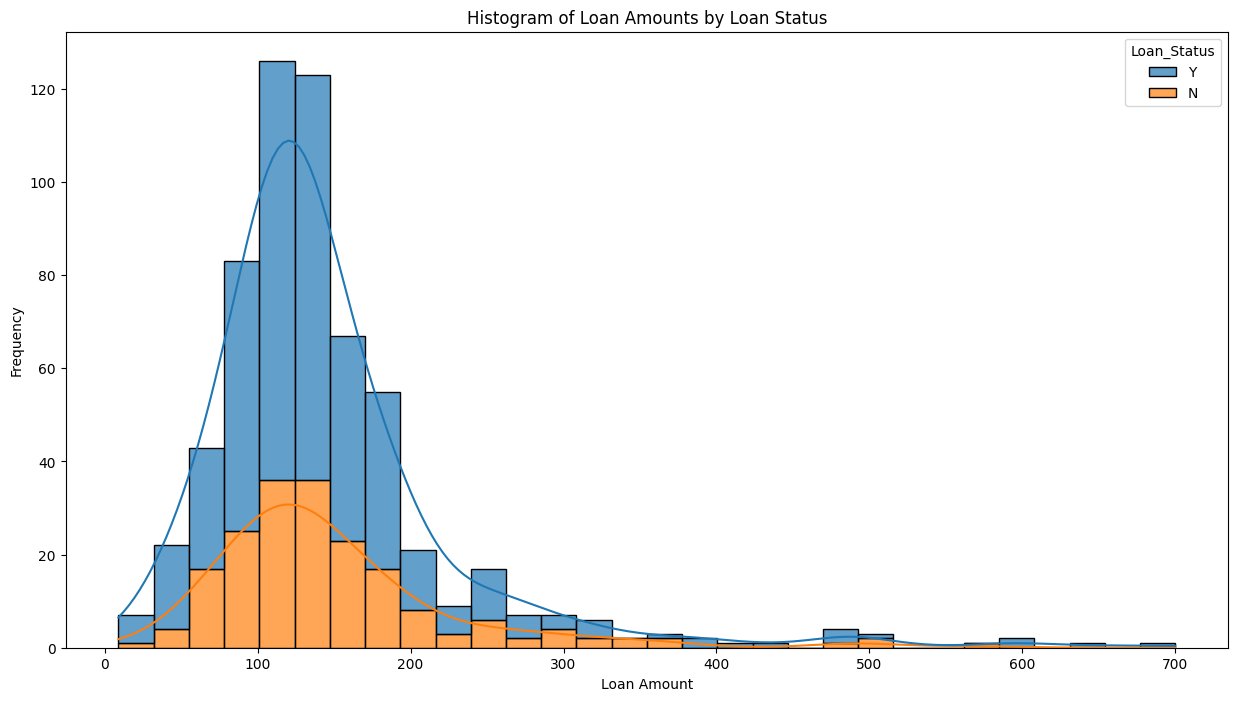

In [44]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='LoanAmount', hue='Loan_Status', multiple='stack', bins=30, alpha=0.7,label='Loan_Status',kde=True)
plt.title('Histogram of Loan Amounts by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

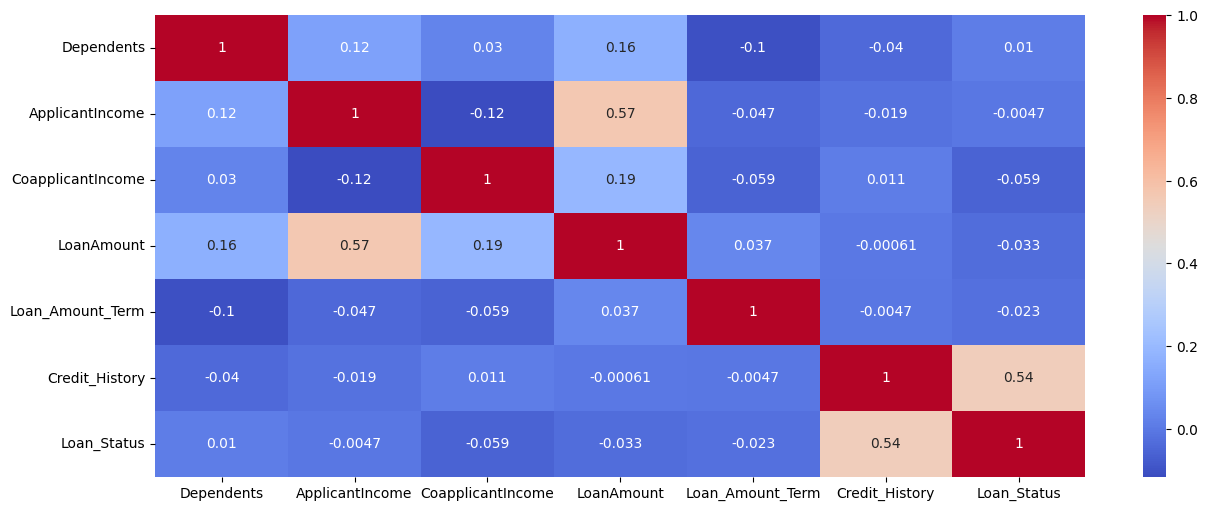

In [45]:
plt.figure(figsize=(15,6))
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float).astype(int)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Label Encoding

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

Feature Scaling

In [47]:
features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
X = df[features]
y = df['Loan_Status']

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42, shuffle=False
)

In [50]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features] = scaler.fit_transform(X_train[features])
X_test_scaled[features] = scaler.transform(X_test[features])

**Model Building**

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.6666666666666666
Precision: 0.6776859504132231
Recall   : 0.9761904761904762
F1 Score : 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.68      0.98      0.80        84

    accuracy                           0.67       123
   macro avg       0.34      0.49      0.40       123
weighted avg       0.46      0.67      0.55       123


Confusion Matrix:
 [[ 0 39]
 [ 2 82]]


In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.5609756097560976
Precision: 0.6744186046511628
Recall   : 0.6904761904761905
F1 Score : 0.6823529411764706

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.28      0.29        39
           1       0.67      0.69      0.68        84

    accuracy                           0.56       123
   macro avg       0.49      0.49      0.49       123
weighted avg       0.55      0.56      0.56       123


Confusion Matrix:
 [[11 28]
 [26 58]]


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.6097560975609756
Precision: 0.6914893617021277
Recall   : 0.7738095238095238
F1 Score : 0.7303370786516854

Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.26      0.29        39
           1       0.69      0.77      0.73        84

    accuracy                           0.61       123
   macro avg       0.52      0.52      0.51       123
weighted avg       0.58      0.61      0.59       123


Confusion Matrix:
 [[10 29]
 [19 65]]


Comparison between all models

In [62]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.666667   0.677686  0.976190  0.800000
1        Decision Tree  0.560976   0.674419  0.690476  0.682353
2        Random Forest  0.609756   0.691489  0.773810  0.730337
